# 07 - Final cleaned HDF5 Panel A vs CORSIKA peak matching

This notebook is the final presentable HDF5 Panel A comparison using the thresholded pulse diagnostics produced by:

`notebooks/06_latest_h5_thresholded_pulse_selection_diagnostics.ipynb`

Main real-pulse input:

`outputs/tables/latest_h5_panel_A_thresholded_pulse_features_all.csv`

The cleaned real sample uses a preliminary amplitude selection:

- `THRESHOLD_MV = 18.0` mV defines pulse start/end after local baseline subtraction.
- `MIN_PEAK_MV = 50.0` mV removes the low-amplitude diagnostic population from the final comparison.
- `MAX_PEAK_MV = 900.0` mV excludes saturated or near-saturated real pulses.
- SNR is **not** used as a hard cut here; `snr_peak` and `baseline_rms_mV` remain diagnostics only.

Low-amplitude pulses below 50 mV are not silently deleted from the workflow. They remain in the full diagnostic table from notebook 06 and are excluded here only from the final cleaned morphology comparison.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_CORSIKA = PROJECT_ROOT / "data/raw/corsika/DATA_PROCESADA_ANTONIO_ROMERO.csv"
DATA_H5_PANEL_A = PROJECT_ROOT / "data/raw/Test_Panel/03A_040526_1h50m_AMP5_C5_thr0_82.h5"
INPUT_FEATURES = PROJECT_ROOT / "outputs/tables/latest_h5_panel_A_thresholded_pulse_features_all.csv"
OUTPUT_TABLES = PROJECT_ROOT / "outputs/tables"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs/figures"
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Input features exists:", INPUT_FEATURES.exists(), INPUT_FEATURES)
print("Panel A HDF5 exists:", DATA_H5_PANEL_A.exists(), DATA_H5_PANEL_A)
print("CORSIKA exists:", DATA_CORSIKA.exists(), DATA_CORSIKA)


Project root: c:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework
Input features exists: True c:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\tables\latest_h5_panel_A_thresholded_pulse_features_all.csv
Panel A HDF5 exists: True c:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\data\raw\Test_Panel\03A_040526_1h50m_AMP5_C5_thr0_82.h5
CORSIKA exists: True c:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\data\raw\corsika\DATA_PROCESADA_ANTONIO_ROMERO.csv


In [2]:
import copy
import json
from bisect import bisect_left

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import LogNorm

try:
    from scipy.stats import ks_2samp
except Exception:
    ks_2samp = None

from tambo_sipm import load_simulation_config
from tambo_sipm.io import (
    build_photon_events,
    detector_summary,
    load_romero_photon_table,
    load_test_panel_h5_samples,
)
from tambo_sipm.simulation import build_calibration_config
from tambo_sipm.simulation.batch import simulate_feature_row_from_photon_event
from tambo_sipm.detector import simulate_detector_event_from_config
from tambo_sipm.plotting import plot_waveform_overlay, save_figure

plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 10
print("Imports OK")


Imports OK


In [3]:
PREFIX = "latest_h5_panel_A_final"

THRESHOLD_MV = 18.0
MIN_PEAK_MV = 50.0
MAX_PEAK_MV = 900.0
MIN_SAMPLES_ABOVE_THRESHOLD = 3
MIN_WIDTH_NS = 16.0
MAX_WIDTH_NS = 600.0

N_MATCH_TARGET = 20_000
N_SIM_POOL = 100_000
RANDOM_SEED = 42
TEMPORAL_BIN_NS = 8.0
N_OVERLAY_WAVEFORMS = 250

VOLTAGE_SCALE_MV_PER_PE = 0.12
PDE = 0.41
ETA_TRANSPORT = 0.025
TAU_F_NS = 220.0
ARRIVAL_SPREAD_NS = 20.0

FEATURE_THRESHOLD_MV = THRESHOLD_MV
N_PRETRIGGER_SAMPLES = 3

print("Threshold for pulse boundaries [mV]:", THRESHOLD_MV)
print("Minimum peak cut [mV]:", MIN_PEAK_MV)
print("Saturation exclusion peak >= [mV]:", MAX_PEAK_MV)
print("Target matched clean pulses:", N_MATCH_TARGET)
print("Simulated pool target:", N_SIM_POOL)
print("Temporal bin size [ns]:", TEMPORAL_BIN_NS)


Threshold for pulse boundaries [mV]: 18.0
Minimum peak cut [mV]: 50.0
Saturation exclusion peak >= [mV]: 900.0
Target matched clean pulses: 20000
Simulated pool target: 100000
Temporal bin size [ns]: 8.0


## 1. Load thresholded real-pulse diagnostics

The table below comes from notebook 06. It contains all gap-segmented candidate windows, including invalid candidates, so the final cutflow is explicit and reproducible.


In [4]:
if not INPUT_FEATURES.exists():
    raise FileNotFoundError(
        f"Missing {INPUT_FEATURES}. Run notebook 06 before running this final notebook."
    )

features = pd.read_csv(INPUT_FEATURES)
print("Feature rows loaded:", len(features))
print("Columns:", list(features.columns))
display(features.head())
display(features[["peak_mV", "width_ns", "integral_mVns", "snr_peak", "baseline_rms_mV"]].describe())


Feature rows loaded: 426568
Columns: ['candidate_id', 'event_id', 'row_start', 'row_end', 'candidate_start_time_ns', 'candidate_end_time_ns', 'n_samples_candidate', 'source_file', 'panel', 'run_id', 'acquisition_date', 'acquisition_duration', 'threshold_token', 'baseline_mV', 'baseline_rms_mV', 'baseline_method', 'threshold_mV', 'peak_mV', 'snr_peak', 'n_samples_above_threshold', 'valid_threshold_pulse', 'threshold_start_time_ns', 'threshold_end_time_ns', 'threshold_start_sample_index', 'threshold_end_sample_index', 'width_ns', 'integral_mVns', 'rms_mV', 'n_samples_thresholded', 'peak_index_in_candidate']


,candidate_id,event_id,row_start,row_end,candidate_start_time_ns,candidate_end_time_ns,n_samples_candidate,source_file,panel,run_id,...,valid_threshold_pulse,threshold_start_time_ns,threshold_end_time_ns,threshold_start_sample_index,threshold_end_sample_index,width_ns,integral_mVns,rms_mV,n_samples_thresholded,peak_index_in_candidate
0,0,threshold_candidate_A_000000,0,24,6881208.0,6881400.0,25,03A_040526_1h50m_AMP5_C5_thr0_82.h5,A,03A,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,5
1,1,threshold_candidate_A_000001,25,49,29659584.0,29659776.0,25,03A_040526_1h50m_AMP5_C5_thr0_82.h5,A,03A,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3
2,2,threshold_candidate_A_000002,50,81,32668448.0,32668696.0,32,03A_040526_1h50m_AMP5_C5_thr0_82.h5,A,03A,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,5
3,3,threshold_candidate_A_000003,82,120,34656616.0,34656920.0,39,03A_040526_1h50m_AMP5_C5_thr0_82.h5,A,03A,...,True,32.0,72.0,86.0,91.0,40.0,805.688,19.905762,6,5
4,4,threshold_candidate_A_000004,121,161,47076712.0,47077032.0,41,03A_040526_1h50m_AMP5_C5_thr0_82.h5,A,03A,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8


c:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,peak_mV,width_ns,integral_mVns,snr_peak,baseline_rms_mV
count,426568.000000,170329.000000,170329.000000,4.265680e+05,426568.000000
mean,20.176367,69.711347,2322.807417,inf,6.117818
std,18.461214,59.670832,5220.021372,NaN,13.913417
min,0.366000,0.000000,0.000000,6.744908e-01,0.000000
25%,12.444000,24.000000,470.920000,5.452134e+00,1.627895
50%,15.982000,56.000000,1321.504000,7.840955e+00,2.260965
75%,22.570000,104.000000,2743.066050,1.059914e+01,3.255790
max,996.862000,1056.000000,454438.288000,inf,492.619054


## 2. Real-pulse cutflow

The final clean sample applies the requested thresholded-pulse criteria. `snr_peak` and `baseline_rms_mV` are kept only as diagnostics because the previous notebook showed suspicious SNR behavior.


In [5]:
def cutflow_row(step, mask):
    kept = int(mask.sum())
    return {
        "step": step,
        "n_pulses": kept,
        "removed_from_previous": np.nan,
        "retained_fraction_of_all": kept / len(features) if len(features) else np.nan,
    }

all_mask = pd.Series(True, index=features.index)
valid_mask = all_mask & (features["valid_threshold_pulse"] == True)
min_peak_mask = valid_mask & (features["peak_mV"] >= MIN_PEAK_MV)
saturation_mask = min_peak_mask & (features["peak_mV"] < MAX_PEAK_MV)
min_samples_mask = saturation_mask & (features["n_samples_above_threshold"] >= MIN_SAMPLES_ABOVE_THRESHOLD)
width_mask = min_samples_mask & (features["width_ns"] >= MIN_WIDTH_NS) & (features["width_ns"] <= MAX_WIDTH_NS)
final_mask = width_mask & (features["integral_mVns"] > 0)

cutflow = pd.DataFrame([
    cutflow_row("all candidates", all_mask),
    cutflow_row("valid threshold pulses", valid_mask),
    cutflow_row("after minimum peak", min_peak_mask),
    cutflow_row("after saturation removal", saturation_mask),
    cutflow_row("after minimum samples above threshold", min_samples_mask),
    cutflow_row("after width range", width_mask),
    cutflow_row("final clean real sample", final_mask),
])
cutflow["removed_from_previous"] = cutflow["n_pulses"].shift(1) - cutflow["n_pulses"]
cutflow.loc[0, "removed_from_previous"] = 0
cutflow.to_csv(OUTPUT_TABLES / f"{PREFIX}_real_selection_cutflow.csv", index=False)
display(cutflow)

real_clean = features[
    (features["valid_threshold_pulse"] == True)
    & (features["peak_mV"] >= MIN_PEAK_MV)
    & (features["peak_mV"] < MAX_PEAK_MV)
    & (features["n_samples_above_threshold"] >= MIN_SAMPLES_ABOVE_THRESHOLD)
    & (features["width_ns"] >= MIN_WIDTH_NS)
    & (features["width_ns"] <= MAX_WIDTH_NS)
    & (features["integral_mVns"] > 0)
].copy().reset_index(drop=True)
real_clean["match_peak_mV"] = pd.to_numeric(real_clean["peak_mV"], errors="coerce")

print("Clean HDF5 Panel A pulses available after all agreed cuts:", len(real_clean))
print("The final matched sample will be selected after simulated valid CORSIKA pulses are known.")
display(real_clean[["event_id", "peak_mV", "width_ns", "integral_mVns", "n_samples_above_threshold", "snr_peak", "baseline_rms_mV"]].head())
display(real_clean[["peak_mV", "width_ns", "integral_mVns", "rms_mV", "snr_peak", "baseline_rms_mV"]].describe())


,step,n_pulses,removed_from_previous,retained_fraction_of_all
0,all candidates,426568,0.0,1.000000
1,valid threshold pulses,170329,256239.0,0.399301
2,after minimum peak,14536,155793.0,0.034077
3,after saturation removal,14519,17.0,0.034037
4,after minimum samples above threshold,14519,0.0,0.034037
5,after width range,14505,14.0,0.034004
6,final clean real sample,14505,0.0,0.034004


Clean HDF5 Panel A pulses available after all agreed cuts: 14505
The final matched sample will be selected after simulated valid CORSIKA pulses are known.


,event_id,peak_mV,width_ns,integral_mVns,n_samples_above_threshold,snr_peak,baseline_rms_mV
0,threshold_candidate_A_000023,64.050,224.0,9069.480001,29,12.646702,5.064562
1,threshold_candidate_A_000033,66.185,192.0,7982.703999,25,17.849329,3.707983
2,threshold_candidate_A_000038,51.606,176.0,6584.095999,23,14.265480,3.617544
3,threshold_candidate_A_000048,62.952,200.0,7749.928003,26,15.819874,3.979298
4,threshold_candidate_A_000062,50.020,176.0,6437.696000,23,17.283826,2.894035


,peak_mV,width_ns,integral_mVns,rms_mV,snr_peak,baseline_rms_mV
count,14505.000000,14505.000000,14505.000000,14505.000000,14505.000000,14505.000000
mean,82.259667,192.798621,10645.929609,54.851537,9.051235,44.666873
std,53.525933,53.506681,9150.976728,29.957072,9.304919,47.476040
min,50.020000,16.000000,770.064000,33.645004,0.688575,0.904386
25%,55.754000,160.000000,6413.296000,39.946093,1.036622,3.979298
50%,65.453000,184.000000,8078.840000,45.461110,1.865907,48.384651
75%,86.132000,224.000000,11433.840000,57.397791,15.995067,72.622196
max,846.253000,512.000000,195798.288000,512.321994,88.235655,492.619054


## 3. Load CORSIKA photon events

This uses the existing project pipeline. As in the exploratory HDF5 notebooks, all available CORSIKA detectors are used here as an exploratory simulation pool unless a later physics review restricts the detector choice.


In [6]:
corsika_table = load_romero_photon_table(DATA_CORSIKA)
print("Detector summary:")
display(detector_summary(corsika_table))

available_detectors = sorted(corsika_table["Detector"].dropna().astype(int).unique())
print("Available detectors:", available_detectors)
print("Exploratory note: using all CORSIKA detectors for the simulated pool.")

def build_all_detector_events(corsika_dataframe):
    event_tables = []
    for detector in available_detectors:
        events = build_photon_events(corsika_dataframe, detector=int(detector)).copy()
        events["detector"] = int(detector)
        if "source_row" in events.columns:
            events["event_id"] = [f"corsika_d{int(detector)}_row{int(row)}" for row in events["source_row"]]
        else:
            events["event_id"] = [f"corsika_d{int(detector)}_idx{idx}" for idx in range(len(events))]
        event_tables.append(events)
    return pd.concat(event_tables, ignore_index=True)

corsika_events_all = build_all_detector_events(corsika_table)
print("CORSIKA events using all detectors:", len(corsika_events_all))
display(corsika_events_all.head())
display(corsika_events_all["detector"].value_counts().sort_index())
corsika_events_all.to_csv(OUTPUT_TABLES / f"{PREFIX}_corsika_all_detectors_events.csv", index=False)


Detector summary:


,Detector,rows,unique_showers,total_photons,mean_photons,median_photons,min_photons,max_photons
0,0.0,26777,9862,763901469,28528.269373,5387.0,949,18807617
1,1.0,6616,4737,90889255,13737.795496,3327.5,949,2946734
2,2.0,6472,4632,82816395,12796.105532,3287.5,950,2508031
3,3.0,6417,4508,87813188,13684.461275,3359.0,949,1897897


Available detectors: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Exploratory note: using all CORSIKA detectors for the simulated pool.
CORSIKA events using all detectors: 46282


,event_id,source_row,detector,shower,particle_id,particle_name,particle_category,generated_photons,n_hits,particle_name_original,t,x,y,ek,carga,masa_MeV,energia_detectada_poli_MeV,tiempo_deteccion
0,corsika_d0_row2,2,0,18,1,gamma,electromagnetic,63228,1,foton,2.669530,0.250841,0.125899,474.3080,0,0.00,7.903448,5.440774
1,corsika_d0_row6,6,0,56,6,mu-,muonic,17156,1,muon-,4.166519,-0.225720,-0.097985,930.5940,-1,105.66,2.144515,8.491790
2,corsika_d0_row8,8,0,63,1,gamma,electromagnetic,2527,1,foton,2.351932,0.406301,-0.186175,18.1535,0,0.00,0.315862,4.793476
3,corsika_d0_row10,10,0,68,1,gamma,electromagnetic,2613,1,foton,6.082793,-0.707285,-0.190728,19.0195,0,0.00,0.326669,12.397351
4,corsika_d0_row11,11,0,71,1,gamma,electromagnetic,2079,1,foton,4.841286,-0.471563,0.054370,13.6359,0,0.00,0.259903,9.867033


detector
0    26777
1     6616
2     6472
3     6417
Name: count, dtype: int64

## 4. Simulation configuration

The fixed methodology parameters are preserved:

- `voltage_scale_mV_per_pe = 0.12`
- `pde = 0.41`

The effective/tuned parameters are applied only to the copied in-notebook config object, not to any YAML file.


In [7]:
base_config = load_simulation_config()
matched_config = build_calibration_config(
    copy.deepcopy(base_config),
    transport_efficiency=ETA_TRANSPORT,
    tau_f_ns=TAU_F_NS,
    arrival_spread_ns=ARRIVAL_SPREAD_NS,
)

assert matched_config["voltage_conversion"]["voltage_scale_mV_per_pe"] == VOLTAGE_SCALE_MV_PER_PE
assert matched_config["photon_transport"]["pde"] == PDE

print("Fixed voltage_scale_mV_per_pe:", matched_config["voltage_conversion"]["voltage_scale_mV_per_pe"])
print("Fixed PDE:", matched_config["photon_transport"]["pde"])
print("transport_efficiency:", matched_config["photon_transport"]["transport_efficiency"])
print("tau_f_ns:", matched_config["sipm_response"]["tau_f_ns"])
print("arrival_spread_ns:", matched_config["sipm_response"]["arrival_spread_ns"])


Fixed voltage_scale_mV_per_pe: 0.12
Fixed PDE: 0.41
transport_efficiency: 0.025
tau_f_ns: 220.0
arrival_spread_ns: 20.0


## 5. Generate simulated feature pool

`N_SIM_POOL = 100000` is configurable at the top of the notebook. If the CORSIKA event table contains fewer unique photon events than requested, events are sampled with replacement but each detector simulation receives a unique random seed.


In [8]:
def simulate_feature_pool_with_seeds(photon_events, config, n_events=100_000, random_seed=42, threshold_mV=18.0, n_pretrigger_samples=3):
    replace = n_events > len(photon_events)
    selected_events = photon_events.sample(n=n_events, replace=replace, random_state=random_seed).reset_index(drop=True)
    rows = []
    for local_index, (_, event_row) in enumerate(selected_events.iterrows()):
        simulation_seed = int(random_seed * 1_000_000 + local_index)
        rng = np.random.default_rng(simulation_seed)
        feature_row = simulate_feature_row_from_photon_event(
            event_row=event_row,
            config=config,
            threshold_mV=threshold_mV,
            n_pretrigger_samples=n_pretrigger_samples,
            rng=rng,
        )
        feature_row["simulation_seed"] = simulation_seed
        feature_row["pool_local_index"] = local_index
        feature_row["source_corsika_event_id"] = str(event_row.get("event_id", local_index))
        feature_row["event_id"] = f"sim_pool_{local_index:06d}"
        rows.append(feature_row)
    return pd.DataFrame(rows)

sim_pool_features = simulate_feature_pool_with_seeds(
    photon_events=corsika_events_all,
    config=matched_config,
    n_events=N_SIM_POOL,
    random_seed=RANDOM_SEED,
    threshold_mV=FEATURE_THRESHOLD_MV,
    n_pretrigger_samples=N_PRETRIGGER_SAMPLES,
)

sim_quality = (
    np.isfinite(pd.to_numeric(sim_pool_features["peak_mV"], errors="coerce"))
    & np.isfinite(pd.to_numeric(sim_pool_features["integral_mVns"], errors="coerce"))
    & np.isfinite(pd.to_numeric(sim_pool_features["width_ns"], errors="coerce"))
    & (pd.to_numeric(sim_pool_features["peak_mV"], errors="coerce") < MAX_PEAK_MV)
    & (pd.to_numeric(sim_pool_features["integral_mVns"], errors="coerce") > 0)
    & (pd.to_numeric(sim_pool_features["width_ns"], errors="coerce") > 0)
)
sim_valid = sim_pool_features[sim_quality].copy().reset_index(drop=True)
sim_valid["match_peak_mV"] = pd.to_numeric(sim_valid["peak_mV"], errors="coerce")

print("Simulated pool rows:", len(sim_pool_features))
print("Simulated valid rows after equivalent quality filters:", len(sim_valid))
display(sim_valid[["event_id", "detector", "generated_photons", "peak_mV", "width_ns", "integral_mVns", "simulation_seed"]].head())
display(sim_valid[["peak_mV", "width_ns", "integral_mVns", "rms_mV"]].describe())

sim_pool_features.to_csv(OUTPUT_TABLES / f"{PREFIX}_sim_pool_features_all.csv", index=False)
sim_valid.to_csv(OUTPUT_TABLES / f"{PREFIX}_sim_pool_features_valid.csv", index=False)


Simulated pool rows: 100000
Simulated valid rows after equivalent quality filters: 9886


,event_id,detector,generated_photons,peak_mV,width_ns,integral_mVns,simulation_seed
0,sim_pool_000000,0,65124,34.790039,88.0,2480.957031,42000000
1,sim_pool_000006,0,52585,33.813477,88.0,2419.433594,42000006
2,sim_pool_000014,0,51141,30.639648,80.0,2099.609375,42000014
3,sim_pool_000024,0,28292,19.409180,24.0,455.566406,42000024
4,sim_pool_000027,0,77390,42.602539,96.0,3148.437500,42000027


,peak_mV,width_ns,integral_mVns,rms_mV
count,9886.000000,9886.000000,9886.000000,9886.000000
mean,59.196705,89.936476,5262.271487,43.386538
std,70.463056,52.621845,8184.590911,44.744277
min,18.066406,8.000000,144.531250,18.066406
25%,22.338867,48.000000,951.904297,20.723103
50%,33.203125,88.000000,2414.550781,27.236014
75%,61.767578,136.000000,5862.670898,43.816087
max,522.094727,192.000000,57734.863281,329.080813


## 6. One-to-one peak matching without replacement

The primary final matching uses peak only. This controls amplitude so that the remaining plots focus on morphology: integral, width, RMS, and waveform shape.


In [9]:
def greedy_peak_match_without_replacement(real_df, sim_df, peak_column="match_peak_mV"):
    real_sorted = real_df.reset_index(names="real_original_index").sort_values(peak_column).reset_index(drop=True)
    sim_sorted = sim_df.reset_index(names="sim_original_index").sort_values(peak_column).reset_index(drop=True)
    available_positions = list(range(len(sim_sorted)))
    available_peaks = sim_sorted[peak_column].to_numpy(dtype=float).tolist()

    match_rows = []
    selected_sim_positions = []

    for match_id, real_row in real_sorted.iterrows():
        real_peak = float(real_row[peak_column])
        insertion = bisect_left(available_peaks, real_peak)
        candidate_indices = []
        if insertion < len(available_peaks):
            candidate_indices.append(insertion)
        if insertion > 0:
            candidate_indices.append(insertion - 1)
        if not candidate_indices:
            raise RuntimeError("No simulated candidates remain during matching.")

        best_local_index = min(candidate_indices, key=lambda idx: abs(available_peaks[idx] - real_peak))
        sim_peak = float(available_peaks.pop(best_local_index))
        best_global_position = available_positions.pop(best_local_index)
        sim_row = sim_sorted.iloc[best_global_position]
        selected_sim_positions.append(best_global_position)

        match_rows.append({
            "match_id": int(match_id),
            "real_original_index": int(real_row["real_original_index"]),
            "sim_original_index": int(sim_row["sim_original_index"]),
            "real_event_id": str(real_row["event_id"]),
            "simulated_event_id": str(sim_row["event_id"]),
            "real_match_peak_mV": real_peak,
            "simulated_match_peak_mV": sim_peak,
            "delta_peak_mV": sim_peak - real_peak,
            "abs_delta_peak_mV": abs(sim_peak - real_peak),
        })

    match_table = pd.DataFrame(match_rows)
    matched_real = real_sorted.copy()
    matched_sim = sim_sorted.iloc[selected_sim_positions].copy().reset_index(drop=True)
    matched_real["match_id"] = match_table["match_id"].to_numpy(dtype=int)
    matched_sim["match_id"] = match_table["match_id"].to_numpy(dtype=int)
    matched_sim["matched_real_event_id"] = match_table["real_event_id"].to_numpy()
    matched_sim["abs_delta_peak_mV"] = match_table["abs_delta_peak_mV"].to_numpy(dtype=float)
    return matched_real, matched_sim, match_table

N_MATCH = min(N_MATCH_TARGET, len(real_clean), len(sim_valid))
if N_MATCH <= 0:
    raise ValueError(
        f"No matchable pulses remain: {len(real_clean)} clean real vs {len(sim_valid)} valid simulated."
    )

if N_MATCH < N_MATCH_TARGET:
    print(
        f"Requested {N_MATCH_TARGET} matched clean pulses, but using {N_MATCH} because "
        f"HDF5 clean = {len(real_clean)} and simulated valid = {len(sim_valid)}."
    )
else:
    print(f"Using requested {N_MATCH} matched clean pulses.")

real_sample = real_clean.sample(n=N_MATCH, random_state=RANDOM_SEED).reset_index(drop=True)
sim_match_pool = sim_valid.sample(n=N_MATCH, random_state=RANDOM_SEED + 1).reset_index(drop=True)

real_sample.to_csv(OUTPUT_TABLES / f"{PREFIX}_real_clean_sample.csv", index=False)
sim_match_pool.to_csv(OUTPUT_TABLES / f"{PREFIX}_sim_valid_sample_for_matching.csv", index=False)

matched_real, matched_sim, peak_match_table = greedy_peak_match_without_replacement(real_sample, sim_match_pool)
print("Matched pairs:", len(peak_match_table))
display(peak_match_table.describe())
display(peak_match_table.head())

matched_real.to_csv(OUTPUT_TABLES / f"{PREFIX}_matched_real.csv", index=False)
matched_sim.to_csv(OUTPUT_TABLES / f"{PREFIX}_matched_simulated.csv", index=False)
peak_match_table.to_csv(OUTPUT_TABLES / f"{PREFIX}_peak_match_table.csv", index=False)


Requested 20000 matched clean pulses, but using 9886 because HDF5 clean = 14505 and simulated valid = 9886.
Matched pairs: 9886


,match_id,real_original_index,sim_original_index,real_match_peak_mV,simulated_match_peak_mV,delta_peak_mV,abs_delta_peak_mV
count,9886.000000,9886.000000,9886.000000,9886.000000,9886.000000,9886.000000,9886.000000
mean,4942.500000,4942.500000,4942.500000,81.845161,59.196705,-22.648456,52.579517
std,2853.986715,2853.986715,2853.986715,51.950779,70.463056,74.489865,57.418282
min,0.000000,0.000000,0.000000,50.020000,18.066406,-828.186594,0.028828
25%,2471.250000,2471.250000,2471.250000,55.937000,22.338867,-53.484133,19.258313
50%,4942.500000,4942.500000,4942.500000,65.514000,33.203125,-24.990875,39.146812
75%,7413.750000,7413.750000,7413.750000,86.132000,61.767578,9.185578,65.359082
max,9885.000000,9885.000000,9885.000000,846.253000,522.094727,251.132727,828.186594


,match_id,real_original_index,sim_original_index,real_event_id,simulated_event_id,real_match_peak_mV,simulated_match_peak_mV,delta_peak_mV,abs_delta_peak_mV
0,0,272,8424,threshold_candidate_A_078245,sim_pool_077799,50.02,50.048828,0.028828,0.028828
1,1,3757,2447,threshold_candidate_A_056007,sim_pool_094924,50.02,50.048828,0.028828,0.028828
2,2,4392,9015,threshold_candidate_A_255434,sim_pool_002068,50.02,50.048828,0.028828,0.028828
3,3,4438,7220,threshold_candidate_A_357138,sim_pool_001641,50.02,50.048828,0.028828,0.028828
4,4,2671,5455,threshold_candidate_A_169217,sim_pool_013230,50.02,50.048828,0.028828,0.028828


## 7. Matching summary


In [10]:
def finite_series(df, column):
    values = pd.to_numeric(df[column], errors="coerce")
    return values[np.isfinite(values)]

def maybe_ks(real_values, sim_values):
    real_values = np.asarray(real_values, dtype=float)
    sim_values = np.asarray(sim_values, dtype=float)
    real_values = real_values[np.isfinite(real_values)]
    sim_values = sim_values[np.isfinite(sim_values)]
    if ks_2samp is None or len(real_values) == 0 or len(sim_values) == 0:
        return np.nan, np.nan
    result = ks_2samp(real_values, sim_values)
    return float(result.statistic), float(result.pvalue)

peak_ks, peak_ks_p = maybe_ks(matched_real["match_peak_mV"], matched_sim["match_peak_mV"])
integral_ks, integral_ks_p = maybe_ks(matched_real["integral_mVns"], matched_sim["integral_mVns"])
width_ks, width_ks_p = maybe_ks(matched_real["width_ns"], matched_sim["width_ns"])

summary = pd.DataFrame([{
    "n_match_target": N_MATCH_TARGET,
    "n_real_clean": len(real_clean),
    "n_real_used": len(matched_real),
    "match_limiting_sample": "real_clean" if len(real_clean) <= len(sim_valid) else "sim_valid",
    "n_simulated_pool": len(sim_pool_features),
    "n_simulated_valid": len(sim_valid),
    "n_matched": len(matched_real),
    "mean_peak_real_mV": finite_series(matched_real, "match_peak_mV").mean(),
    "median_peak_real_mV": finite_series(matched_real, "match_peak_mV").median(),
    "mean_peak_sim_mV": finite_series(matched_sim, "match_peak_mV").mean(),
    "median_peak_sim_mV": finite_series(matched_sim, "match_peak_mV").median(),
    "mean_integral_real_mVns": finite_series(matched_real, "integral_mVns").mean(),
    "median_integral_real_mVns": finite_series(matched_real, "integral_mVns").median(),
    "mean_integral_sim_mVns": finite_series(matched_sim, "integral_mVns").mean(),
    "median_integral_sim_mVns": finite_series(matched_sim, "integral_mVns").median(),
    "mean_width_real_ns": finite_series(matched_real, "width_ns").mean(),
    "median_width_real_ns": finite_series(matched_real, "width_ns").median(),
    "mean_width_sim_ns": finite_series(matched_sim, "width_ns").mean(),
    "median_width_sim_ns": finite_series(matched_sim, "width_ns").median(),
    "ks_peak_statistic": peak_ks,
    "ks_peak_pvalue": peak_ks_p,
    "ks_integral_statistic": integral_ks,
    "ks_integral_pvalue": integral_ks_p,
    "ks_width_statistic": width_ks,
    "ks_width_pvalue": width_ks_p,
    "mean_abs_delta_peak_mV": peak_match_table["abs_delta_peak_mV"].mean(),
    "median_abs_delta_peak_mV": peak_match_table["abs_delta_peak_mV"].median(),
    "max_abs_delta_peak_mV": peak_match_table["abs_delta_peak_mV"].max(),
    "threshold_mV": THRESHOLD_MV,
    "min_peak_mV": MIN_PEAK_MV,
    "max_peak_mV": MAX_PEAK_MV,
    "temporal_bin_ns": TEMPORAL_BIN_NS,
    "voltage_scale_mV_per_pe": VOLTAGE_SCALE_MV_PER_PE,
    "pde": PDE,
    "transport_efficiency": ETA_TRANSPORT,
    "tau_f_ns": TAU_F_NS,
    "arrival_spread_ns": ARRIVAL_SPREAD_NS,
    "snr_used_as_hard_cut": False,
    "exploratory_all_corsika_detectors": True,
}])
summary.to_csv(OUTPUT_TABLES / f"{PREFIX}_matching_summary.csv", index=False)
display(summary.T)


,0
n_match_target,20000
n_real_clean,14505
n_real_used,9886
match_limiting_sample,sim_valid
n_simulated_pool,100000
n_simulated_valid,9886
n_matched,9886
mean_peak_real_mV,81.845161
median_peak_real_mV,65.514
mean_peak_sim_mV,59.196705


## 8. Normalized 1D histograms

All comparison histograms are normalized. Width uses fixed 8 ns bins.


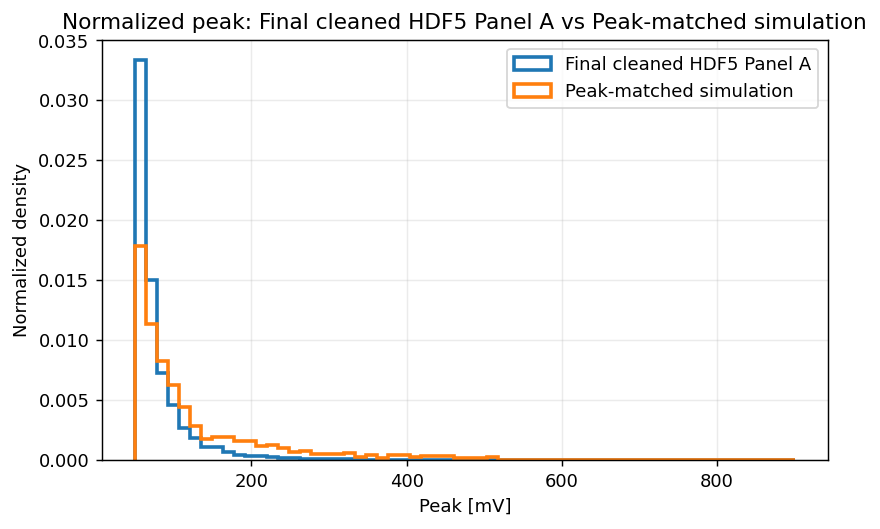

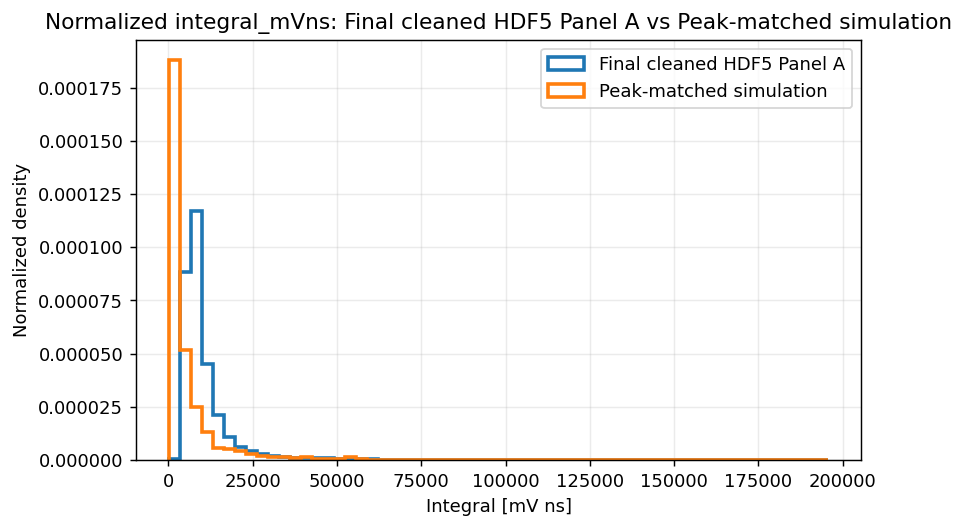

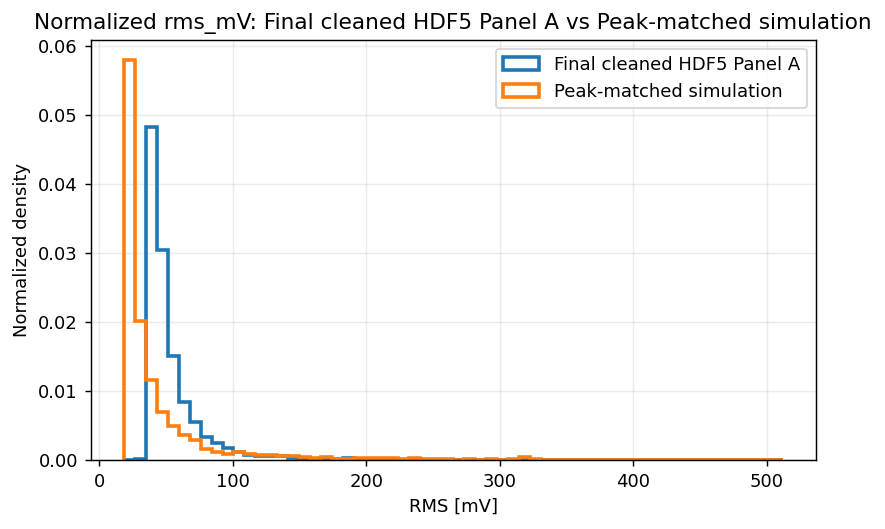

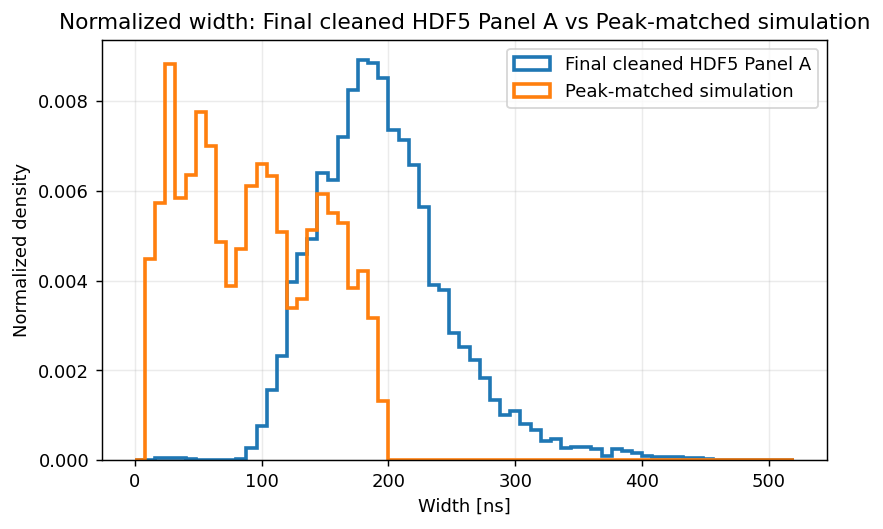

In [11]:
def finite_pair(real_df, sim_df, column):
    rv = pd.to_numeric(real_df[column], errors="coerce")
    sv = pd.to_numeric(sim_df[column], errors="coerce")
    mask = np.isfinite(rv) & np.isfinite(sv)
    return rv[mask].to_numpy(dtype=float), sv[mask].to_numpy(dtype=float)

def common_linear_bins(a, b, n_bins=50, lower=None, upper=None):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    values = np.concatenate([a[np.isfinite(a)], b[np.isfinite(b)]])
    if lower is None:
        lower = float(np.min(values))
    if upper is None:
        upper = float(np.max(values))
    if lower == upper:
        upper = lower + 1.0
    return np.linspace(lower, upper, n_bins + 1)

def temporal_bins_8ns(a, b, lower=0.0):
    values = np.concatenate([np.asarray(a, dtype=float), np.asarray(b, dtype=float)])
    values = values[np.isfinite(values)]
    upper = TEMPORAL_BIN_NS * np.ceil(values.max() / TEMPORAL_BIN_NS) + TEMPORAL_BIN_NS
    return np.arange(lower, upper + TEMPORAL_BIN_NS, TEMPORAL_BIN_NS)

def normalized_hist_overlay(real_values, sim_values, bins, xlabel, title, output_name):
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    ax.hist(real_values, bins=bins, density=True, histtype="step", linewidth=2.0, label="Final cleaned HDF5 Panel A")
    ax.hist(sim_values, bins=bins, density=True, histtype="step", linewidth=2.0, label="Peak-matched simulation")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Normalized density")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.25)
    save_figure(fig, OUTPUT_FIGURES / output_name)
    plt.show()

real_peak, sim_peak = finite_pair(matched_real, matched_sim, "match_peak_mV")
normalized_hist_overlay(
    real_peak,
    sim_peak,
    common_linear_bins(real_peak, sim_peak, n_bins=60, lower=MIN_PEAK_MV, upper=MAX_PEAK_MV),
    "Peak [mV]",
    "Normalized peak: Final cleaned HDF5 Panel A vs Peak-matched simulation",
    f"{PREFIX}_hist_peak_normalized.png",
)

for column, xlabel, output_name in [
    ("integral_mVns", "Integral [mV ns]", f"{PREFIX}_hist_integral_normalized.png"),
    ("rms_mV", "RMS [mV]", f"{PREFIX}_hist_rms_normalized.png"),
]:
    real_values, sim_values = finite_pair(matched_real, matched_sim, column)
    bins = common_linear_bins(real_values, sim_values, n_bins=60)
    normalized_hist_overlay(
        real_values,
        sim_values,
        bins,
        xlabel,
        f"Normalized {column}: Final cleaned HDF5 Panel A vs Peak-matched simulation",
        output_name,
    )

real_width, sim_width = finite_pair(matched_real, matched_sim, "width_ns")
normalized_hist_overlay(
    real_width,
    sim_width,
    temporal_bins_8ns(real_width, sim_width),
    "Width [ns]",
    "Normalized width: Final cleaned HDF5 Panel A vs Peak-matched simulation",
    f"{PREFIX}_hist_width_8ns_normalized.png",
)


## 9. Normalized 2D histograms

The color scale is normalized by the number of entries in each panel. Width axes use fixed 8 ns bins.


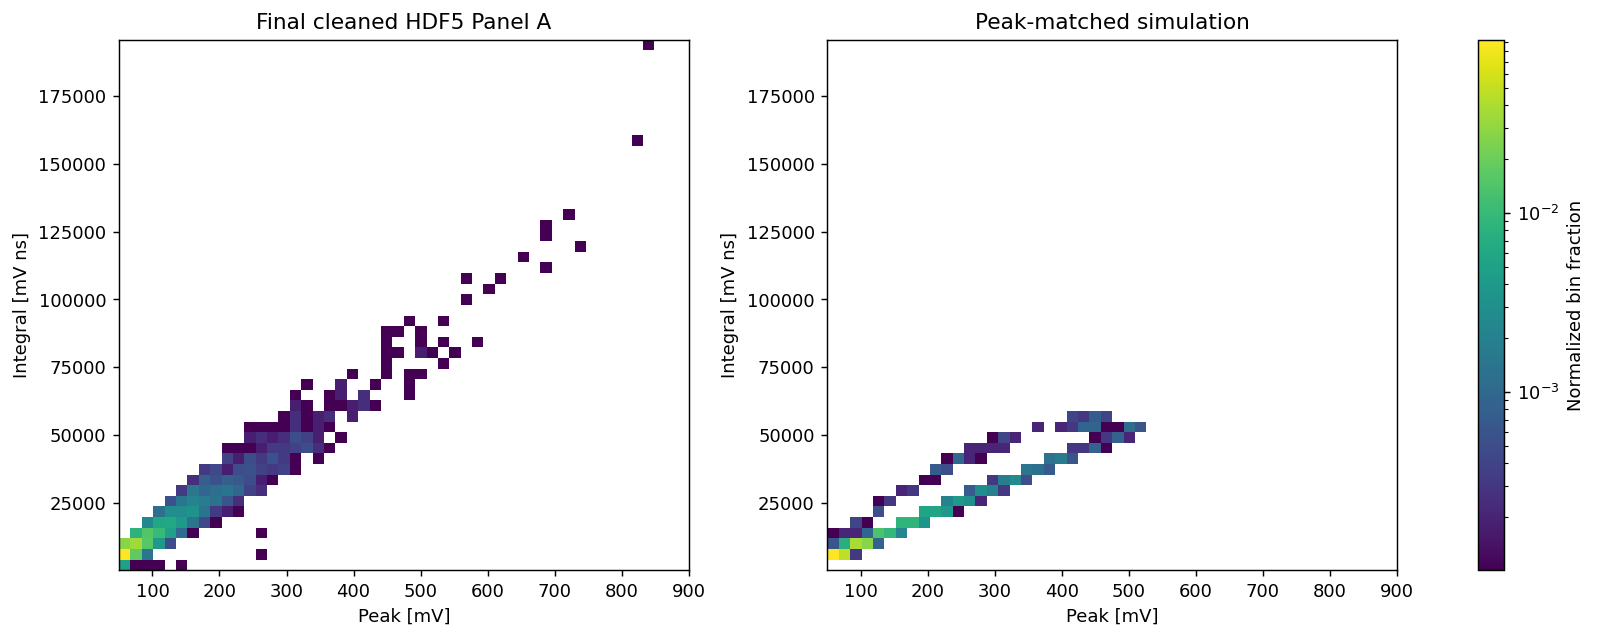

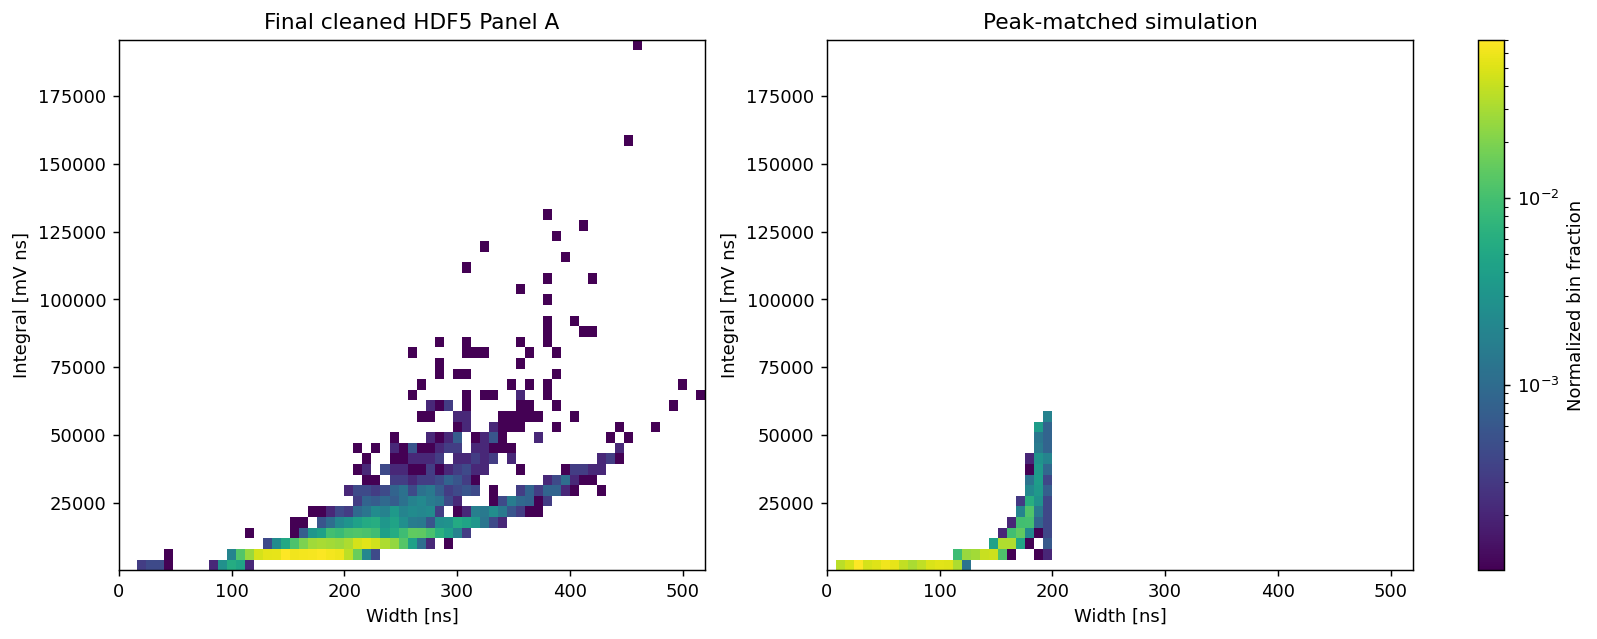

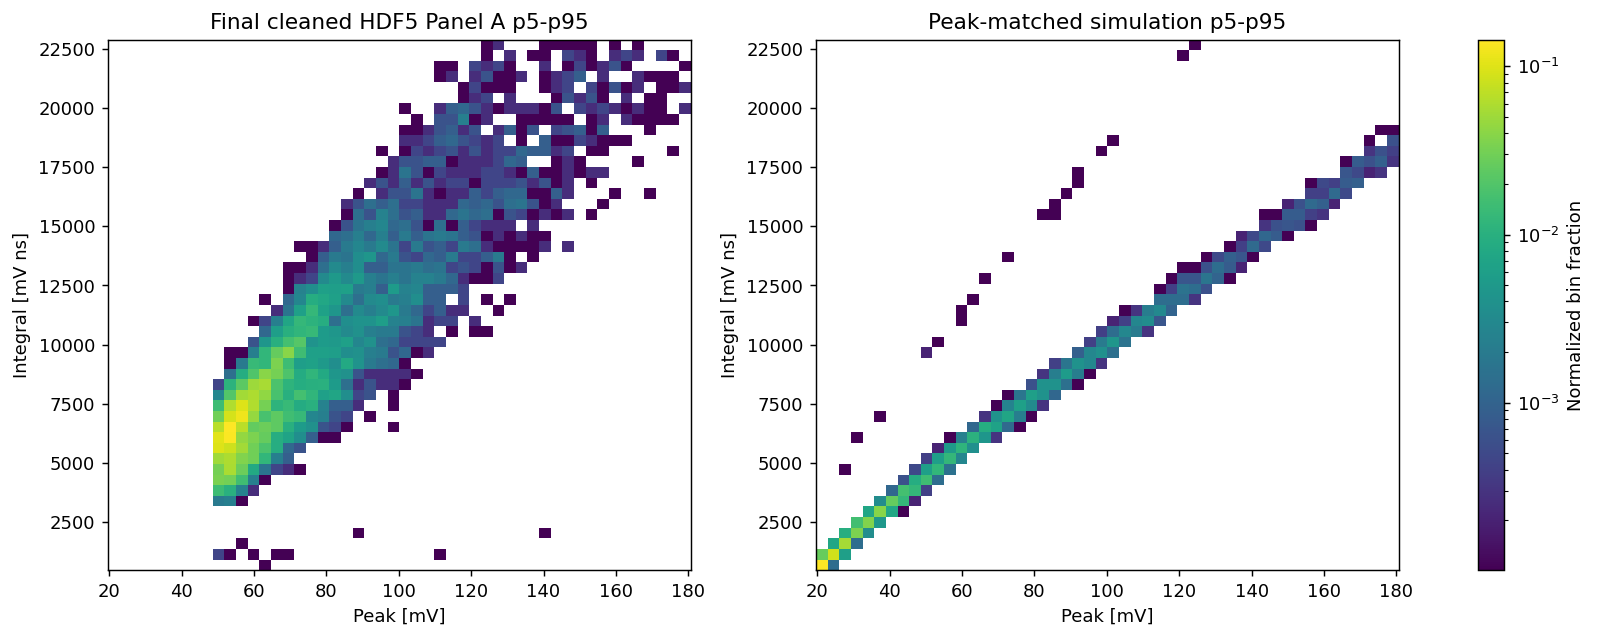

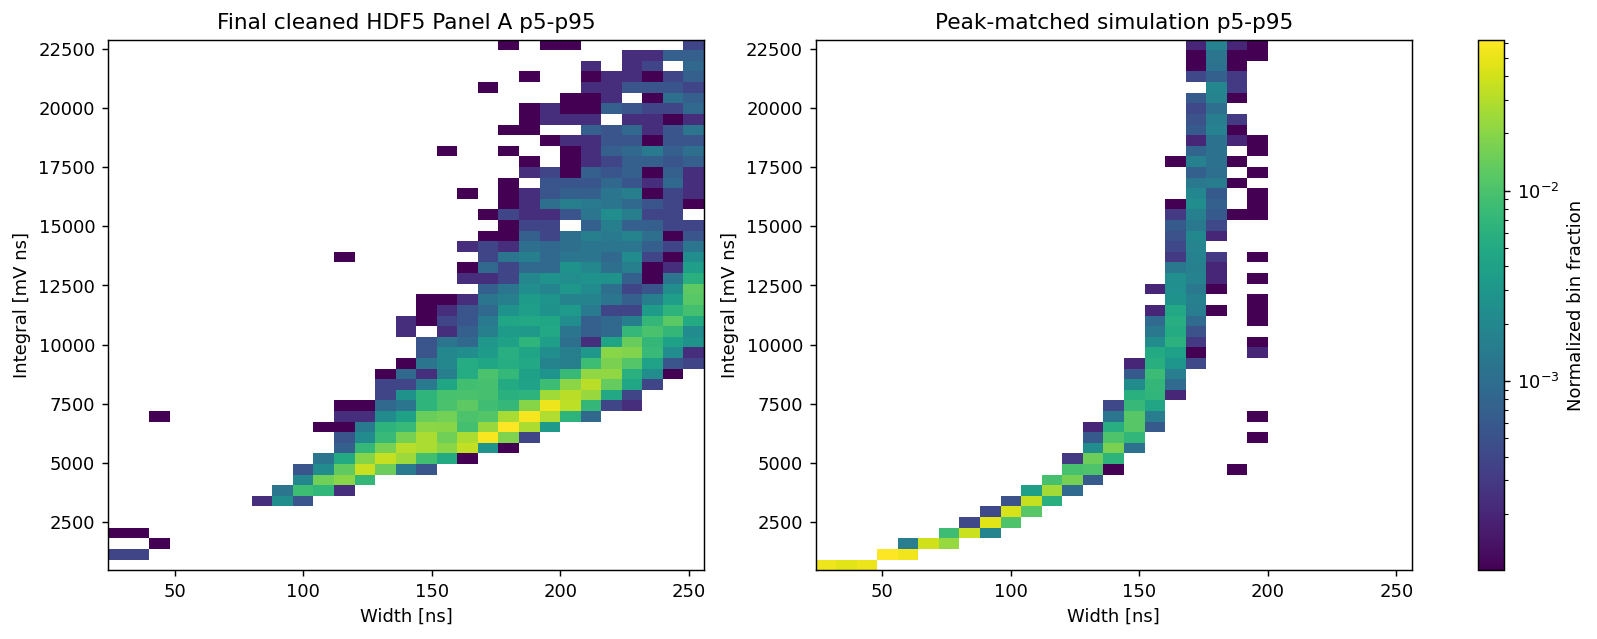

In [12]:
def normalized_hist2d(ax, x, y, x_bins, y_bins, title, xlabel, ylabel):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    weights = np.ones(mask.sum(), dtype=float) / mask.sum() if mask.sum() else None
    hist = ax.hist2d(
        x[mask],
        y[mask],
        bins=[x_bins, y_bins],
        weights=weights,
        norm=LogNorm(),
        cmap="viridis",
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return hist

def side_by_side_hist2d(real_df, sim_df, x_column, y_column, x_bins, y_bins, xlabel, ylabel, output_name, subtitle=""):
    fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8), constrained_layout=True)
    h0 = normalized_hist2d(
        axes[0],
        pd.to_numeric(real_df[x_column], errors="coerce"),
        pd.to_numeric(real_df[y_column], errors="coerce"),
        x_bins,
        y_bins,
        "Final cleaned HDF5 Panel A" + subtitle,
        xlabel,
        ylabel,
    )
    h1 = normalized_hist2d(
        axes[1],
        pd.to_numeric(sim_df[x_column], errors="coerce"),
        pd.to_numeric(sim_df[y_column], errors="coerce"),
        x_bins,
        y_bins,
        "Peak-matched simulation" + subtitle,
        xlabel,
        ylabel,
    )
    fig.colorbar(h1[3], ax=axes, label="Normalized bin fraction")
    save_figure(fig, OUTPUT_FIGURES / output_name)
    plt.show()

peak_bins = common_linear_bins(matched_real["match_peak_mV"], matched_sim["match_peak_mV"], n_bins=50, lower=MIN_PEAK_MV, upper=MAX_PEAK_MV)
integral_bins = common_linear_bins(matched_real["integral_mVns"], matched_sim["integral_mVns"], n_bins=50)
width_bins = temporal_bins_8ns(matched_real["width_ns"], matched_sim["width_ns"])

side_by_side_hist2d(
    matched_real,
    matched_sim,
    "match_peak_mV",
    "integral_mVns",
    peak_bins,
    integral_bins,
    "Peak [mV]",
    "Integral [mV ns]",
    f"{PREFIX}_hist2d_integral_vs_peak_normalized.png",
)

side_by_side_hist2d(
    matched_real,
    matched_sim,
    "width_ns",
    "integral_mVns",
    width_bins,
    integral_bins,
    "Width [ns]",
    "Integral [mV ns]",
    f"{PREFIX}_hist2d_integral_vs_width_8ns_normalized.png",
)

def percentile_bins(real_df, sim_df, column, n_bins=50, temporal=False):
    values = pd.concat([
        pd.to_numeric(real_df[column], errors="coerce"),
        pd.to_numeric(sim_df[column], errors="coerce"),
    ])
    values = values[np.isfinite(values)]
    lo, hi = values.quantile([0.05, 0.95])
    if temporal:
        lo = TEMPORAL_BIN_NS * np.floor(lo / TEMPORAL_BIN_NS)
        hi = TEMPORAL_BIN_NS * np.ceil(hi / TEMPORAL_BIN_NS)
        return np.arange(lo, hi + TEMPORAL_BIN_NS, TEMPORAL_BIN_NS)
    return np.linspace(float(lo), float(hi), n_bins + 1)

side_by_side_hist2d(
    matched_real,
    matched_sim,
    "match_peak_mV",
    "integral_mVns",
    percentile_bins(matched_real, matched_sim, "match_peak_mV", n_bins=50),
    percentile_bins(matched_real, matched_sim, "integral_mVns", n_bins=50),
    "Peak [mV]",
    "Integral [mV ns]",
    f"{PREFIX}_hist2d_integral_vs_peak_p5_p95_normalized.png",
    subtitle=" p5-p95",
)

side_by_side_hist2d(
    matched_real,
    matched_sim,
    "width_ns",
    "integral_mVns",
    percentile_bins(matched_real, matched_sim, "width_ns", temporal=True),
    percentile_bins(matched_real, matched_sim, "integral_mVns", n_bins=50),
    "Width [ns]",
    "Integral [mV ns]",
    f"{PREFIX}_hist2d_integral_vs_width_8ns_p5_p95_normalized.png",
    subtitle=" p5-p95",
)


## 10. Waveform overlays

The real overlay is drawn directly from the HDF5 samples using the selected clean candidate windows and the local baseline from notebook 06. The simulated overlay is reconstructed from the stored simulation seeds.


Loading HDF5 samples for real waveform overlay...


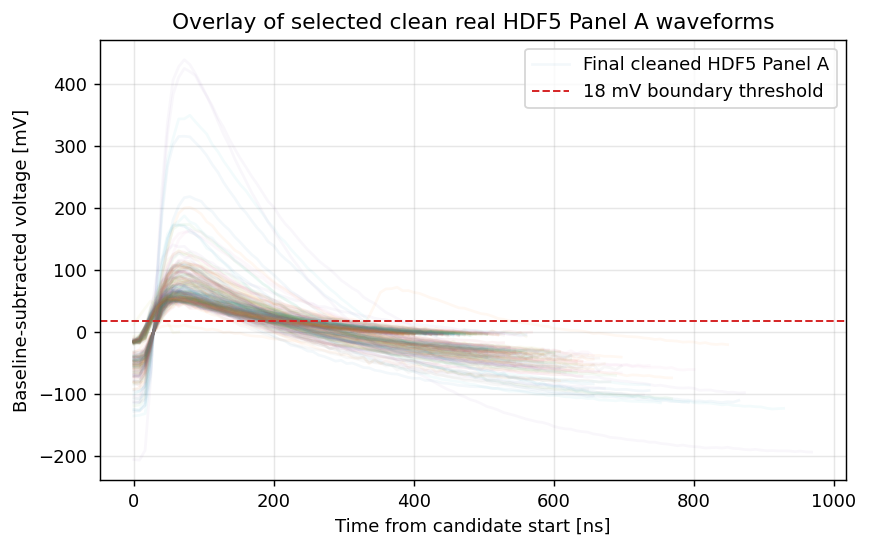

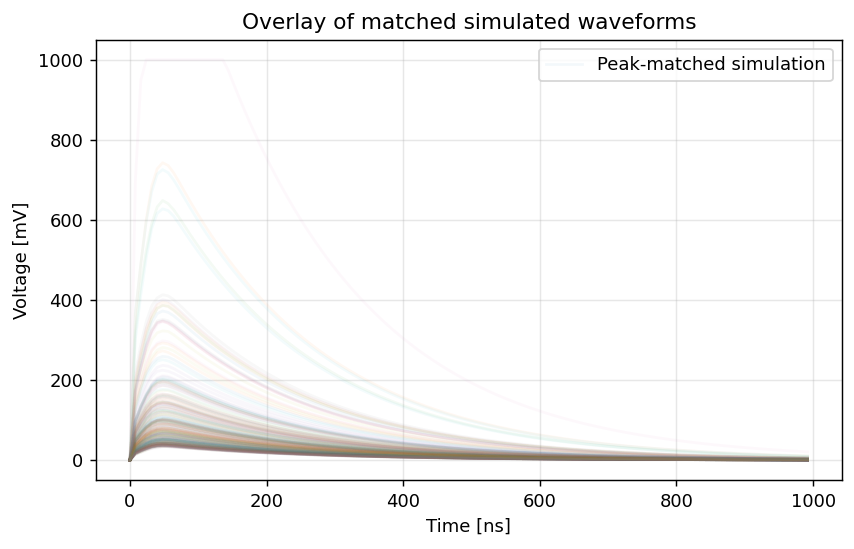

In [13]:
def selected_waveform_rows(df, n=N_OVERLAY_WAVEFORMS):
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=RANDOM_SEED).copy()

overlay_real_rows = selected_waveform_rows(matched_real)
print("Loading HDF5 samples for real waveform overlay...")
samples_A = load_test_panel_h5_samples(DATA_H5_PANEL_A, voltage_unit="auto")

def real_waveform_from_row(row, samples):
    start = int(row["row_start"])
    end = int(row["row_end"])
    candidate = samples.iloc[start : end + 1]
    t = candidate["time_ns"].to_numpy(dtype=float)
    v = candidate["voltage_mV"].to_numpy(dtype=float) - float(row["baseline_mV"])
    return t - t[0], v

real_waveforms = [
    real_waveform_from_row(row, samples_A)
    for _, row in overlay_real_rows.iterrows()
]

fig, ax = plt.subplots(figsize=(7.4, 4.4))
plot_waveform_overlay(
    real_waveforms,
    xlabel="Time from candidate start [ns]",
    ylabel="Baseline-subtracted voltage [mV]",
    label="Final cleaned HDF5 Panel A",
    alpha=0.05,
    ax=ax,
)
ax.axhline(THRESHOLD_MV, color="tab:red", linestyle="--", linewidth=1.1, label="18 mV boundary threshold")
ax.set_title("Overlay of selected clean real HDF5 Panel A waveforms")
ax.legend()
save_figure(fig, OUTPUT_FIGURES / f"{PREFIX}_overlay_selected_clean_real_waveforms.png")
plt.show()

def reconstruct_simulated_waveform(row, config):
    rng = np.random.default_rng(int(row["simulation_seed"]))
    result = simulate_detector_event_from_config(
        generated_photons=int(row["generated_photons"]),
        config=config,
        rng=rng,
    )
    return result.sampled_time_ns, result.digitized_voltage_mV

overlay_sim_rows = selected_waveform_rows(matched_sim)
sim_waveforms = [
    reconstruct_simulated_waveform(row, matched_config)
    for _, row in overlay_sim_rows.iterrows()
]

fig, ax = plt.subplots(figsize=(7.4, 4.4))
plot_waveform_overlay(
    sim_waveforms,
    xlabel="Time [ns]",
    ylabel="Voltage [mV]",
    label="Peak-matched simulation",
    alpha=0.05,
    ax=ax,
)
ax.set_title("Overlay of matched simulated waveforms")
ax.legend()
save_figure(fig, OUTPUT_FIGURES / f"{PREFIX}_overlay_matched_simulated_waveforms.png")
plt.show()


## 11. Final markdown summary


In [14]:
summary_row = summary.iloc[0].to_dict()
low_amp_count = int(((features["valid_threshold_pulse"] == True) & (features["peak_mV"] < MIN_PEAK_MV)).sum())
saturated_count = int(((features["valid_threshold_pulse"] == True) & (features["peak_mV"] >= MAX_PEAK_MV)).sum())

summary_md = f"""# Latest HDF5 Panel A Final Analysis Summary

## Inputs

- Real feature table: `{INPUT_FEATURES.name}`
- Latest Panel A HDF5 file: `{DATA_H5_PANEL_A.name}`
- CORSIKA table: `{DATA_CORSIKA.name}`

## Selection Criteria

- Pulse boundary threshold: `{THRESHOLD_MV:g} mV` after local baseline subtraction.
- Minimum peak: `{MIN_PEAK_MV:g} mV`.
- Saturation exclusion: `peak_mV < {MAX_PEAK_MV:g} mV`.
- Minimum samples above threshold: `{MIN_SAMPLES_ABOVE_THRESHOLD}`.
- Width range: `{MIN_WIDTH_NS:g}` to `{MAX_WIDTH_NS:g} ns`.
- Positive integral required.
- SNR is not used as a final hard cut; `snr_peak` and `baseline_rms_mV` are diagnostics.

## Pulse Counts

- All candidate windows: `{int(cutflow.loc[cutflow["step"] == "all candidates", "n_pulses"].iloc[0])}`.
- Valid threshold pulses: `{int(cutflow.loc[cutflow["step"] == "valid threshold pulses", "n_pulses"].iloc[0])}`.
- Low-amplitude valid pulses below `{MIN_PEAK_MV:g} mV`: `{low_amp_count}`. These remain a diagnostic population and are excluded only from the final cleaned comparison.
- Saturated or near-saturated valid pulses at/above `{MAX_PEAK_MV:g} mV`: `{saturated_count}`.
- Requested matched-pair target: `{N_MATCH_TARGET}`.
- Final clean real sample available: `{len(real_clean)}`.
- Simulated pool generated: `{len(sim_pool_features)}`.
- Simulated valid candidates after agreed filters: `{len(sim_valid)}`.
- Final matched pairs used: `{len(matched_real)}`.
- Matching uses `min(N_MATCH_TARGET, len(real_clean), len(sim_valid))`, so the smaller valid sample sets the final number of pairs.

## Why 50 mV

`50 mV` is used as a preliminary minimum peak cut because notebook 06 identified the region below this scale as a low-amplitude diagnostic population where noise, weak candidates, and threshold-edge behavior can dominate. This cut is not claiming those pulses are unphysical; it creates a cleaner presentation sample for morphology comparison.

## Why 18 mV

`18 mV` is used only to define pulse start/end after local baseline subtraction. It is a boundary/feature-extraction threshold, not the final event-quality threshold.

## Why Saturated Pulses Are Excluded

Pulses with `peak_mV >= {MAX_PEAK_MV:g} mV` are excluded because saturation or near-saturation can distort peak, integral, and width. Including them would bias the real-vs-simulation morphology comparison.

## Final Comparison Result

Peak matching controls the amplitude distribution directly. The matched peak KS statistic is `{summary_row["ks_peak_statistic"]:.6g}` when SciPy is available. The integral KS statistic is `{summary_row["ks_integral_statistic"]:.6g}` and the width KS statistic is `{summary_row["ks_width_statistic"]:.6g}`.

Median real/sim integral: `{summary_row["median_integral_real_mVns"]:.6g}` vs `{summary_row["median_integral_sim_mVns"]:.6g}` mV ns.

Median real/sim width: `{summary_row["median_width_real_ns"]:.6g}` vs `{summary_row["median_width_sim_ns"]:.6g}` ns.

## Remaining Discrepancy

After controlling for peak, differences in integral and width remain the key diagnostic. This points to missing temporal response effects in the current model, especially analog/electronic shaping, optical/electronic time dispersion, baseline behavior, trigger/acquisition effects, or a more realistic readout response.

## Recommended Next Improvement

Add an analog/electronic shaping and baseline model before retuning the optical/effective parameters. The fixed methodology parameters remain `voltage_scale_mV_per_pe = {VOLTAGE_SCALE_MV_PER_PE}` and `pde = {PDE}`.
"""

summary_path = OUTPUT_TABLES / f"{PREFIX}_analysis_summary.md"
summary_path.write_text(summary_md, encoding="utf-8")
display(Markdown(summary_md))
print("Wrote:", summary_path)
print("Output tables:", OUTPUT_TABLES)
print("Output figures:", OUTPUT_FIGURES)


# Latest HDF5 Panel A Final Analysis Summary

## Inputs

- Real feature table: `latest_h5_panel_A_thresholded_pulse_features_all.csv`
- Latest Panel A HDF5 file: `03A_040526_1h50m_AMP5_C5_thr0_82.h5`
- CORSIKA table: `DATA_PROCESADA_ANTONIO_ROMERO.csv`

## Selection Criteria

- Pulse boundary threshold: `18 mV` after local baseline subtraction.
- Minimum peak: `50 mV`.
- Saturation exclusion: `peak_mV < 900 mV`.
- Minimum samples above threshold: `3`.
- Width range: `16` to `600 ns`.
- Positive integral required.
- SNR is not used as a final hard cut; `snr_peak` and `baseline_rms_mV` are diagnostics.

## Pulse Counts

- All candidate windows: `426568`.
- Valid threshold pulses: `170329`.
- Low-amplitude valid pulses below `50 mV`: `155793`. These remain a diagnostic population and are excluded only from the final cleaned comparison.
- Saturated or near-saturated valid pulses at/above `900 mV`: `17`.
- Requested matched-pair target: `20000`.
- Final clean real sample available: `14505`.
- Simulated pool generated: `100000`.
- Simulated valid candidates after agreed filters: `9886`.
- Final matched pairs used: `9886`.
- Matching uses `min(N_MATCH_TARGET, len(real_clean), len(sim_valid))`, so the smaller valid sample sets the final number of pairs.

## Why 50 mV

`50 mV` is used as a preliminary minimum peak cut because notebook 06 identified the region below this scale as a low-amplitude diagnostic population where noise, weak candidates, and threshold-edge behavior can dominate. This cut is not claiming those pulses are unphysical; it creates a cleaner presentation sample for morphology comparison.

## Why 18 mV

`18 mV` is used only to define pulse start/end after local baseline subtraction. It is a boundary/feature-extraction threshold, not the final event-quality threshold.

## Why Saturated Pulses Are Excluded

Pulses with `peak_mV >= 900 mV` are excluded because saturation or near-saturation can distort peak, integral, and width. Including them would bias the real-vs-simulation morphology comparison.

## Final Comparison Result

Peak matching controls the amplitude distribution directly. The matched peak KS statistic is `0.680154` when SciPy is available. The integral KS statistic is `0.655675` and the width KS statistic is `0.629779`.

Median real/sim integral: `8054.68` vs `2414.55` mV ns.

Median real/sim width: `184` vs `88` ns.

## Remaining Discrepancy

After controlling for peak, differences in integral and width remain the key diagnostic. This points to missing temporal response effects in the current model, especially analog/electronic shaping, optical/electronic time dispersion, baseline behavior, trigger/acquisition effects, or a more realistic readout response.

## Recommended Next Improvement

Add an analog/electronic shaping and baseline model before retuning the optical/effective parameters. The fixed methodology parameters remain `voltage_scale_mV_per_pe = 0.12` and `pde = 0.41`.


Wrote: c:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\tables\latest_h5_panel_A_final_analysis_summary.md
Output tables: c:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\tables
Output figures: c:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures
